# Análisis de regresión logística para pulsación alta

**Objetivo:** Explicar la probabilidad de tener pulsación en reposo alta (`penr = 2`) en función del hábito de fumar (`fumador`) y el peso (`peso`).

**Variables:**
- `penr`: pulsación en reposo (1 = normal, 2 = alta)
- `fumador`: (1 = sí, 2 = no)
- `peso`: peso en kg de 92 hombres adultos.

Se realizará:
- Análisis exploratorio de datos (EDA).
- Ajuste de un modelo de regresión logística.
- Interpretación de coeficientes y odds ratios.
- Diagnóstico completo del modelo (residuos, influencia, bondad de ajuste, curva ROC).

## 1. Carga de librerías 

In [13]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import chi2
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Configuración visual
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# 2. Lectura de los datos

Como el archivo es .dat, observamos que las columnas están separadas por espacios.

In [15]:
# ==========================================
# 2. LECTURA DE LOS DATOS
# ==========================================

datos = pd.read_csv(r'Data/pulso.dat', sep=r'\s+', header=0)

# Verificar tipos y primeras filas

datos.head()

,penr,fumador,peso
0,1,2,69.3700
1,1,2,71.8470
2,1,1,79.2800
3,1,1,94.1450
4,1,2,76.8020


# 3. Inspección inicial

In [16]:
# ==========================================
# 3. INSPECCIÓN INICIAL
# ==========================================

print("Dimensiones del conjunto de datos:")
print(datos.shape)

print("\nInformación de las variables:")
print(datos.info())

print("\nValores faltantes:")
print(datos.isnull().sum())

print("\nPrimeras observaciones:")
display(datos.head(10))

Dimensiones del conjunto de datos:
(92, 3)

Información de las variables:
<class 'pandas.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   penr     92 non-null     int64  
 1   fumador  92 non-null     int64  
 2   peso     92 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 2.3 KB
None

Valores faltantes:
penr       0
fumador    0
peso       0
dtype: int64

Primeras observaciones:


,penr,fumador,peso
0,1,2,69.3700
1,1,2,71.8470
2,1,1,79.2800
3,1,1,94.1450
4,1,2,76.8020
5,1,2,81.7570
6,2,2,74.3250
7,1,2,94.1450
8,1,2,96.6230
9,1,2,68.3790


Tenemos:

$$ \boxed{n=92} $$

y tres variables:

penr,
fumador,
peso

Además, en este conjunto de datos no encontramos valores faltantes.

# 4. Verificar las codificaciones

Este paso es importante.

La variable penr está codificada:

$$ 1=\text{normal} $$ $$ 2=\text{alta} $$

Mientras que fumador:

$$ 1=\text{sí} $$ $$ 2=\text{no} $$


In [17]:
# ==========================================
# 4. FRECUENCIAS DE LAS VARIABLES
# ==========================================

print("Frecuencia de pulsación:")
print(datos["penr"].value_counts().sort_index())

print("\nFrecuencia de fumadores:")
print(datos["fumador"].value_counts().sort_index())

Frecuencia de pulsación:
penr
1    70
2    22
Name: count, dtype: int64

Frecuencia de fumadores:
fumador
1    28
2    64
Name: count, dtype: int64


# Interpretación 

70 hombres con pulsación normal.
22 hombres con pulsación alta.

Por tanto:

$$ \frac{22}{92}\approx 0.2391 $$

aproximadamente el 23.9 % presenta pulsación alta.

# 5. Crear variables adecuadas para el modelo

Aquí tenemos una decisión estadística importante.

Para una regresión logística queremos que la respuesta sea:

$$ Y= \begin{cases} 1 & \text{pulsación alta}\\ 0 & \text{pulsación normal} \end{cases} $$

In [19]:
# ==========================================
# 5. RECODIFICACIÓN DE VARIABLES
# ==========================================

datos["pulso_alta"] = (datos["penr"] == 2).astype(int)

datos["fumador_si"] = (datos["fumador"] == 1).astype(int)

display(datos.head())

,penr,fumador,peso,pulso_alta,fumador_si
0,1,2,69.3700,0,0
1,1,2,71.8470,0,0
2,1,1,79.2800,0,1
3,1,1,94.1450,0,1
4,1,2,76.8020,0,0


No debemos introducir penr directamente como 1 o 2. 
Lo correcto es convertir la respuesta en 0,1.

# 6. Análisis exploratorio
6.1 Estadísticos descriptivos

In [20]:
# ==========================================
# 6.1 ESTADÍSTICOS DESCRIPTIVOS
# ==========================================

datos[["peso"]].describe()

,peso
count,92.0000
mean,71.9228
std,11.7629
min,47.0720
25%,61.9380
50%,71.8470
75%,77.0498
max,106.5330


Interpretación

El peso medio es aproximadamente:

$$ \boxed{71.92\text{ kg}} $$

con una desviación estándar de aproximadamente:

$$ \boxed{11.76\text{ kg}} $$

Existe cierta dispersión y se observa un valor máximo de aproximadamente 106.5 kg.

# 6.2 Distribución de la pulsación

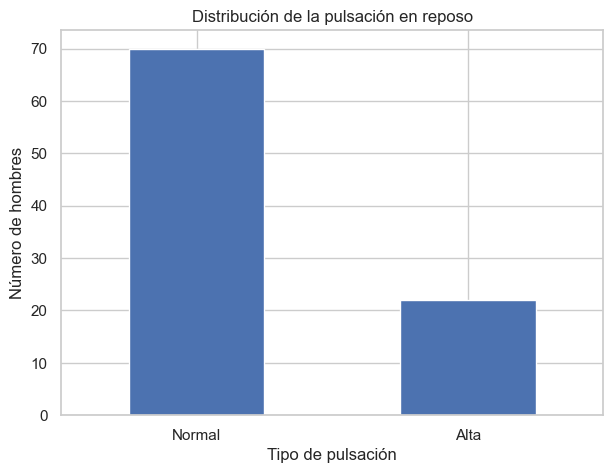

In [21]:
# ==========================================
# 6.2 DISTRIBUCIÓN DE PULSACIÓN
# ==========================================

frecuencia_pulso = datos["pulso_alta"].value_counts().sort_index()

frecuencia_pulso.index = [
    "Normal",
    "Alta"
]

ax = frecuencia_pulso.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribución de la pulsación en reposo")
plt.xlabel("Tipo de pulsación")
plt.ylabel("Número de hombres")
plt.xticks(rotation=0)
plt.show()

Interpretación

La mayoría de los individuos presenta pulsación normal:

$$ 70/92=76.1\% $$

mientras que:

$$ 22/92=23.9\% $$

presenta pulsación alta.

Esto nos indica que la variable respuesta está desbalanceada moderadamente, aunque no en un grado extremo.

# 6.3 Distribución del peso

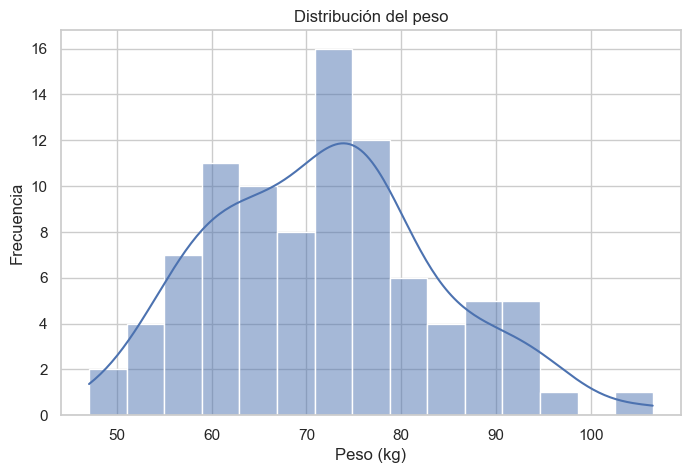

In [22]:
# ==========================================
# 6.3 DISTRIBUCIÓN DEL PESO
# ==========================================

plt.figure(figsize=(8, 5))

sns.histplot(
    datos["peso"],
    kde=True,
    bins=15
)

plt.title("Distribución del peso")
plt.xlabel("Peso (kg)")
plt.ylabel("Frecuencia")

plt.show()

Resumen descriptivo

La mayoría de los hombres del estudio tienen un peso entre 60 y 80 kg.
El peso medio/mediano se sitúa cerca de los 70-73 kg (la curva de densidad lo confirma visualmente).
La distribución es relativamente concentrada, con pocos individuos en los extremos.

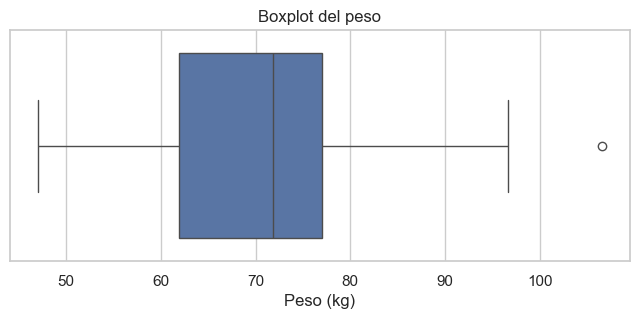

In [23]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=datos["peso"])

plt.title("Boxplot del peso")
plt.xlabel("Peso (kg)")

plt.show()

## 6.4 Pulsación según condición de fumador ##

In [24]:
# ==========================================
# 6.4 PULSACIÓN VS FUMADOR
# ==========================================

tabla_fumador = pd.crosstab(
    datos["fumador_si"],
    datos["pulso_alta"]
)

tabla_fumador.columns = [
    "Pulso normal",
    "Pulso alto"
]

tabla_fumador.index = [
    "No fumador",
    "Fumador"
]

tabla_fumador

,Pulso normal,Pulso alto
No fumador,52,12
Fumador,18,10


In [25]:
# Proporciones dentro de cada grupo
proporcion_fumador = pd.crosstab(
    datos["fumador_si"],
    datos["pulso_alta"],
    normalize="index"
)

proporcion_fumador.columns = [
    "Pulso normal",
    "Pulso alto"
]

proporcion_fumador.index = [
    "No fumador",
    "Fumador"
]

proporcion_fumador

,Pulso normal,Pulso alto
No fumador,0.8125,0.1875
Fumador,0.6429,0.3571


No fumadores: 18.75 % con pulsación alta.
Fumadores: 35.71 % con pulsación alta.

Esto ya sugiere una posible asociación entre fumar y presentar pulsación alta.

# 6.5 Visualización pulsación–fumador

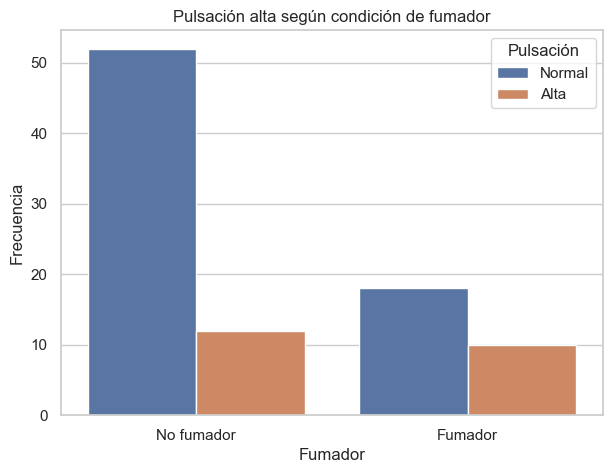

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=datos,
    x="fumador_si",
    hue="pulso_alta"
)

plt.title("Pulsación alta según condición de fumador")
plt.xlabel("Fumador")
plt.ylabel("Frecuencia")

plt.xticks(
    [0, 1],
    ["No fumador", "Fumador"]
)

plt.legend(
    title="Pulsación",
    labels=["Normal", "Alta"]
)

plt.show()

Un fumador en esta muestra tiene casi el doble de probabilidad (35.71% frente a 18.75%) de registrar una pulsación en reposo elevada en comparación con un no fumador, lo que asocia directamente el hábito de fumar con una mayor frecuencia cardíaca alterada.

# 6.6 Pulsación según peso

Ahora queremos explorar si el peso parece relacionarse con la pulsación alta.

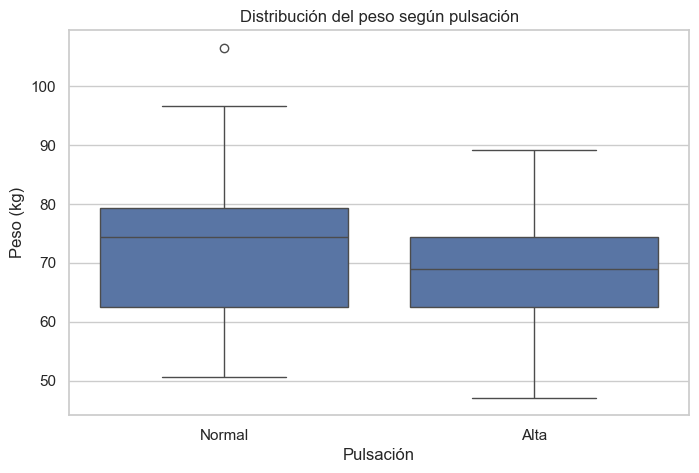

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=datos,
    x="pulso_alta",
    y="peso"
)

plt.title("Distribución del peso según pulsación")
plt.xlabel("Pulsación")
plt.ylabel("Peso (kg)")

plt.xticks(
    [0, 1],
    ["Normal", "Alta"]
)

plt.show()

Estadísticamente, el gráfico demuestra que el exceso de peso no es el factor que altera el ritmo cardíaco en estos hombres. Esto refuerza la conclusión del gráfico anterior: el tabaquismo tiene un impacto real y directo sobre la pulsación, mientras que el peso se comporta de forma inversa o independiente en esta muestra.

Promedios

In [28]:
datos.groupby("pulso_alta")["peso"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
pulso_alta,,,,,,
0,70,73.0508,74.3250,12.3077,50.5410,106.5330
1,22,68.3339,68.8745,9.1722,47.0720,89.1900


los hombres con pulsación alta presentan, en promedio, un peso menor.

# 7. Modelo de regresión logística

Ahora sí entramos en la parte central.

Queremos modelar:

$$ P(Y_i=1) $$

donde:

$$ Y_i= \begin{cases} 1 & \text{pulsación alta}\\ 0 & \text{pulsación normal}. \end{cases} $$

El modelo logístico es:

$$ \boxed{ \log\left( \frac{\pi_i}{1-\pi_i} \right) = \beta_0+ \beta_1\text{fumador}_i+ \beta_2\text{peso}_i } $$

donde

$$ π_i =P(Y_i=1) $$

# 8. Ajustar el modelo

In [29]:
# ==========================================
# 8. MODELO DE REGRESIÓN LOGÍSTICA
# ==========================================

modelo = smf.glm(
    formula="pulso_alta ~ fumador_si + peso",
    data=datos,
    family=sm.families.Binomial()
).fit()

print(modelo.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             pulso_alta   No. Observations:                   92
Model:                            GLM   Df Residuals:                       89
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -46.820
Date:                Mon, 07 Sep 2026   Deviance:                       93.640
Time:                        12:38:10   Pearson chi2:                     88.6
No. Iterations:                     4   Pseudo R-squ. (CS):            0.07903
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9872      1.679      1.183      0.2

El modelo obtenido es aproximadamente:

$$ \boxed{ \widehat{\eta} = 1.987 + 1.193(\text{fumador}) - 0.0505(\text{peso}) } $$

Es decir:

\begin{equation}
\log\left(\frac{\hat{\pi}}{1 - \hat{\pi}}\right) = 1.987 + 1.193 \, \text{fumador} - 0.0505 \, \text{peso}
\end{equation}

	​


9. Interpretación de los coeficientes

Esta es una de las partes más importantes del ejercicio.

9.1 Coeficiente del fumador

Tenemos:

$$ \hat\beta_1=1.193 $$

En regresión logística, el coeficiente está inicialmente expresado en términos de log-odds.

Por tanto:

$$ e^{1.193}=3.297. $$

Es decir:

$$ \boxed{OR_{\text{fumador}}\approx3.30} $$
Interpretación

Manteniendo constante el peso, los fumadores presentan aproximadamente 3.30 veces las odds de tener pulsación alta respecto a los no fumadores.

También podemos obtener el intervalo de confianza:

$$ IC_{95\%}(OR)\approx(1.12,\;9.75). $$

Como el intervalo no contiene 1, existe evidencia estadística de asociación al 5%.

El valor-p es:

$$ \boxed{p=0.031} $$

por lo que el efecto de fumador resulta estadísticamente significativo al nivel del 5%.

9.2 Coeficiente del peso

Tenemos:

$$ \hat\beta_2=-0.0505. $$

El odds ratio por cada kilogramo adicional es:

$$ e^{-0.0505}\approx0.9508. $$

Por tanto:

$$ \boxed{OR_{\text{peso}}\approx0.951} $$
Interpretación

Manteniendo constante la condición de fumador, por cada kilogramo adicional de peso, las odds de presentar pulsación alta se multiplican por aproximadamente:

$$ 0.951. $$

Equivalentemente, disminuyen aproximadamente:

$$ (1-0.9508)\times100\approx4.9\%. $$

Por tanto:

En esta muestra, manteniendo constante el tabaquismo, un aumento de 1 kg en el peso está asociado con una disminución aproximada del 4.9 % en las odds de presentar pulsación alta.

El valor-p es aproximadamente:

$$ \boxed{p=0.041} $$

por lo que también resulta significativo al 5%.

# 10. Obtener los Odds Ratios automáticamente

In [30]:
# ==========================================
# 10. ODDS RATIOS E INTERVALOS DE CONFIANZA
# ==========================================

coeficientes = modelo.params
IC = modelo.conf_int()

resultados_OR = pd.DataFrame({
    "Coeficiente": coeficientes,
    "OR": np.exp(coeficientes),
    "IC_95%_inferior": np.exp(IC[0]),
    "IC_95%_superior": np.exp(IC[1]),
    "p_valor": modelo.pvalues
})

resultados_OR

,Coeficiente,OR,IC_95%_inferior,IC_95%_superior,p_valor
Intercept,1.9872,7.2953,0.2714,196.1013,0.2367
fumador_si,1.1930,3.2969,1.1153,9.7455,0.0310
peso,-0.0505,0.9508,0.9058,0.9980,0.0412


# 11. Evaluación global del modelo

No debemos quedarnos únicamente con los valores-p individuales.

Vamos a comparar el modelo con el modelo nulo.

El modelo nulo solamente tiene intercepto:

$$ \log\left(\frac{\pi}{1-\pi}\right)=\beta_0. $$

El modelo completo agrega:

fumador ,
peso

In [31]:
# ==========================================
# 11. EVALUACIÓN GLOBAL
# ==========================================

print("Deviance nula:", modelo.null_deviance)
print("Deviance residual:", modelo.deviance)
print("AIC:", modelo.aic)

LR = modelo.null_deviance - modelo.deviance

p_LR = chi2.sf(
    LR,
    df=2
)

print("\nPrueba de razón de verosimilitudes")
print("Estadístico LR:", LR)
print("p-valor:", p_LR)

Deviance nula: 101.21389634234723
Deviance residual: 93.63952948308366
AIC: 99.63952948308366

Prueba de razón de verosimilitudes
Estadístico LR: 7.574366859263563
p-valor: 0.022659333664183486


Tenemos aproximadamente:

$$ D_0=101.214 $$

y

$$ D_1=93.640. $$

La diferencia es:

$$ 101.214-93.640=7.574. $$

Con 2 grados de libertad:

$$ \boxed{p\approx0.0227}. $$
Conclusión

Rechazamos

$$ H_0:\beta_1=\beta_2=0 $$

al 5 %.

Por tanto, existe evidencia de que el conjunto de variables fumador y peso aporta información para explicar la probabilidad de pulsación alta.

# 12. Predicciones

In [32]:
# ==========================================
# 12. PROBABILIDADES ESTIMADAS
# ==========================================

datos["prob_alta"] = modelo.predict(datos)

datos[
    ["penr", "fumador", "peso", "pulso_alta", "prob_alta"]
].head(10)

,penr,fumador,peso,pulso_alta,prob_alta
0,1,2,69.3700,0,0.1801
1,1,2,71.8470,0,0.1623
2,1,1,79.2800,0,0.3050
3,1,1,94.1450,0,0.1716
4,1,2,76.8020,0,0.1311
5,1,2,81.7570,0,0.1051
6,2,2,74.3250,1,0.1460
7,1,2,94.1450,0,0.0591
8,1,2,96.6230,0,0.0525
9,1,2,68.3790,0,0.1876


Recordemos que la probabilidad estimada viene dada por:

$$ \boxed{ \hat\pi_i= \frac{e^{\hat\eta_i}} {1+e^{\hat\eta_i}} } $$

donde

$$ \hat\eta_i= 1.987+ 1.193\,fumador_i -0.0505\,peso_i. $$
13. Diagnóstico del modelo

Ahora llegamos a una parte que el profesor probablemente espera que desarrolles con cuidado.

Un modelo puede tener coeficientes significativos y, aun así, presentar problemas de ajuste.

Vamos a revisar:

residuos;
observaciones atípicas;
leverage;
distancia de Cook;
influencia;
multicolinealidad;
bondad de ajuste;
capacidad discriminativa.

# 14. Residuos

In [33]:
# ==========================================
# 14. RESIDUOS
# ==========================================

influencia = modelo.get_influence()

diagnostico = influencia.summary_frame()

diagnostico["resid_pearson"] = modelo.resid_pearson
diagnostico["resid_deviance"] = modelo.resid_deviance

diagnostico[
    [
        "resid_pearson",
        "resid_deviance",
        "standard_resid"
    ]
].head()

,resid_pearson,resid_deviance,standard_resid
0,-0.4686,-0.6301,-0.4725
1,-0.4402,-0.5952,-0.4439
2,-0.6625,-0.8531,-0.6759
3,-0.4552,-0.6137,-0.4694
4,-0.3884,-0.5301,-0.3923


El modelo se está comportando bien con estos primeros datos. Aunque tiende a sobreestimar ligeramente (por el signo negativo), los errores son pequeños, controlados y no hay ningún dato problemático o 'outlier' que esté distorsionando predicciones.

# 15. Residuos vs valores ajustados

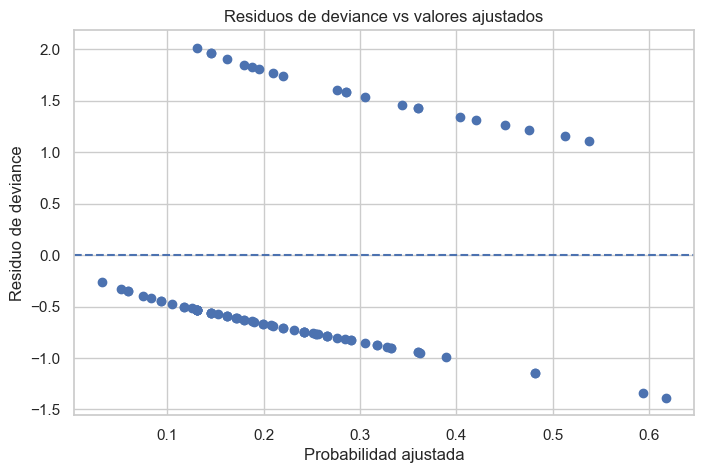

In [34]:
# ==========================================
# 15. RESIDUOS VS VALORES AJUSTADOS
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    modelo.fittedvalues,
    modelo.resid_deviance
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Probabilidad ajustada")
plt.ylabel("Residuo de deviance")
plt.title("Residuos de deviance vs valores ajustados")

plt.show()

El gráfico valida que la estructura de la regresión logística es estadísticamente correcta y limpia. No hay patrones extraños de dispersión (como formas de embudo) ni errores gigantescos que sugieran que debas eliminar datos.

# 16. Identificación de residuos grandes

In [35]:
# ==========================================
# 16. OBSERVACIONES CON RESIDUOS GRANDES
# ==========================================

diagnostico["abs_resid"] = abs(
    diagnostico["standard_resid"]
)

indices_residuos = diagnostico[
    diagnostico["abs_resid"] > 2
].index

datos.loc[
    indices_residuos,
    ["penr", "fumador", "peso", "pulso_alta", "prob_alta"]
]

,penr,fumador,peso,pulso_alta,prob_alta
6,2,2,74.3250,1,0.1460
24,2,2,69.3700,1,0.1801
27,2,2,68.3790,1,0.1876
55,2,2,76.8020,1,0.1311
60,2,2,71.8470,1,0.1623
65,2,2,67.3880,1,0.1953
90,2,2,74.3250,1,0.1460


# 17. Leverage

El leverage mide qué tan alejada está una observación respecto al conjunto de valores de las variables explicativas.

In [36]:
# ==========================================
# 17. LEVERAGE
# ==========================================

diagnostico["leverage"] = diagnostico["hat_diag"]

umbral_leverage = 2 * 3 / len(datos)

print("Umbral aproximado:", umbral_leverage)

diagnostico[
    diagnostico["leverage"] > umbral_leverage
][["leverage"]]

Umbral aproximado: 0.06521739130434782


,leverage
28,0.0707
33,0.0899
85,0.0991
86,0.0819


Utilizamos como referencia:

$$ \frac{2p}{n} $$

donde:

\(p=3\): intercepto + 2 predictores;
\(n=92\).

Entonces:

$$ \frac{2(3)}{92} \approx0.0652. $$

La observación con mayor leverage alcanza aproximadamente:

$$ \boxed{0.0991}. $$

Por tanto, existe al menos una observación con leverage relativamente elevado.

# 18. Distancia de Cook

La distancia de Cook permite evaluar cuánto cambia el ajuste del modelo cuando una observación particular es retirada.

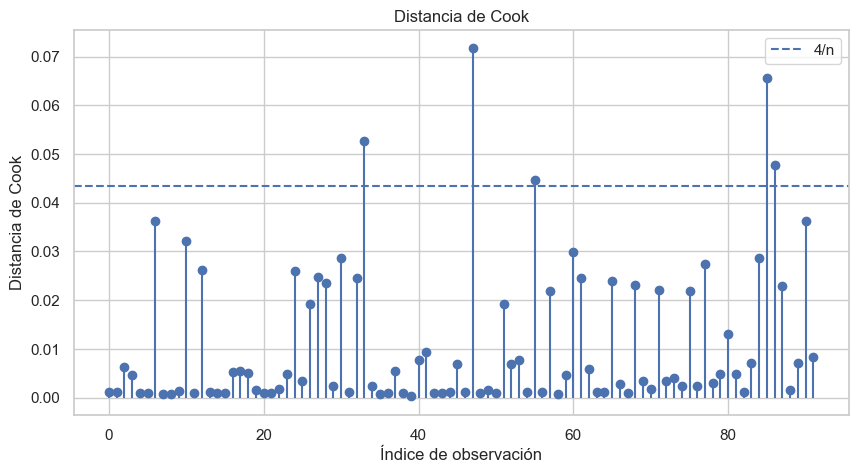

In [37]:
# ==========================================
# 18. DISTANCIA DE COOK
# ==========================================

diagnostico["cooks_d"] = influencia.cooks_distance[0]

plt.figure(figsize=(10, 5))

plt.stem(
    range(len(datos)),
    diagnostico["cooks_d"],
    basefmt=" "
)

plt.axhline(
    4 / len(datos),
    linestyle="--",
    label="4/n"
)

plt.xlabel("Índice de observación")
plt.ylabel("Distancia de Cook")
plt.title("Distancia de Cook")
plt.legend()

plt.show()

A pesar de que el gráfico de residuos anterior no mostraba "outliers" extremos en términos de error puro, este gráfico revela que estos 4 hombres específicos tienen combinaciones de variables tan particulares que están jalando o condicionando los resultados del modelo más que los demás.

Usamos como referencia:

$$ \frac4n = \frac4{92} \approx0.0435. $$

La mayor distancia de Cook es aproximadamente:

$$ \boxed{0.0718}. $$

Por tanto, hay observaciones potencialmente influyentes.

Pero nuevamente:

superar \(4/n\) no significa que automáticamente debamos eliminar la observación.

Debemos investigarla.

# 19. Identificar las observaciones más influyentes

In [38]:
# ==========================================
# 19. OBSERVACIONES INFLUYENTES
# ==========================================

diagnostico["indice"] = datos.index

observaciones_influyentes = (
    diagnostico
    .sort_values("cooks_d", ascending=False)
    .head(10)
)

observaciones_influyentes[
    [
        "indice",
        "cooks_d",
        "leverage",
        "standard_resid",
        "dffits_internal"
    ]
]

,indice,cooks_d,leverage,standard_resid,dffits_internal
47,47,0.0718,0.0516,1.9906,0.4643
85,85,0.0656,0.0991,-1.3378,-0.4437
33,33,0.0528,0.0899,-1.2661,-0.3979
86,86,0.0478,0.0819,1.2683,0.3788
55,55,0.0447,0.0194,2.5999,0.3662
6,6,0.0362,0.0179,2.4404,0.3295
90,90,0.0362,0.0179,2.4404,0.3295
10,10,0.0322,0.0392,1.5399,0.3109
60,60,0.0300,0.0168,2.2911,0.2999
30,30,0.0287,0.0322,1.6066,0.2932


as observaciones que más llaman la atención son aproximadamente los índices:

$$ 47,\;85,\;33,\;86,\;55,\;6,\;90,\ldots $$

Estas observaciones deben revisarse en los datos originales antes de tomar cualquier decisión.

# 20. Multicolinealidad

Aunque solamente tenemos dos predictores, es recomendable comprobarla.

In [39]:
# ==========================================
# 20. MULTICOLINEALIDAD
# ==========================================

X = sm.add_constant(
    datos[["fumador_si", "peso"]]
)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,const,39.1318
1,fumador_si,1.0416
2,peso,1.0416


Para los predictores obtenemos aproximadamente:

$$ \boxed{VIF_{\text{fumador}}\approx1.04} $$ $$ \boxed{VIF_{\text{peso}}\approx1.04} $$

Esto es excelente.

Interpretación

No existe evidencia de multicolinealidad problemática entre peso y condición de fumador.

# 21. Bondad de ajuste — Hosmer-Lemeshow

Podemos utilizar una versión basada en grupos de probabilidades estimadas.

In [40]:
# ==========================================
# 21. HOSMER-LEMESHOW
# ==========================================

datos["grupo_HL"] = pd.qcut(
    datos["prob_alta"],
    q=10,
    duplicates="drop"
)

hl = datos.groupby(
    "grupo_HL",
    observed=True
).agg(
    n=("pulso_alta", "size"),
    observados=("pulso_alta", "sum"),
    esperados=("prob_alta", "sum")
)

hl["obs_normal"] = hl["n"] - hl["observados"]

hl["esp_normal"] = (
    hl["n"] - hl["esperados"]
)

hl["chi"] = (
    (hl["observados"] - hl["esperados"])**2
    / hl["esperados"]
    +
    (hl["obs_normal"] - hl["esp_normal"])**2
    / hl["esp_normal"]
)

HL = hl["chi"].sum()

p_HL = chi2.sf(
    HL,
    8
)

print("Estadístico Hosmer-Lemeshow:", HL)
print("p-valor:", p_HL)

Estadístico Hosmer-Lemeshow: 5.615301277845762
p-valor: 0.690234830935294


Obtenemos aproximadamente:

$$ \boxed{HL=5.615} $$

y

$$ \boxed{p=0.690}. $$
Interpretación

Como:

$$ p>0.05, $$

no tenemos evidencia suficiente para rechazar la hipótesis de buen ajuste.

Es decir:

No se detecta una discrepancia estadísticamente significativa entre las frecuencias observadas y las esperadas por el modelo.

# 22. Curva ROC y AUC

Finalmente podemos estudiar la capacidad del modelo para discriminar entre pulsación normal y alta.

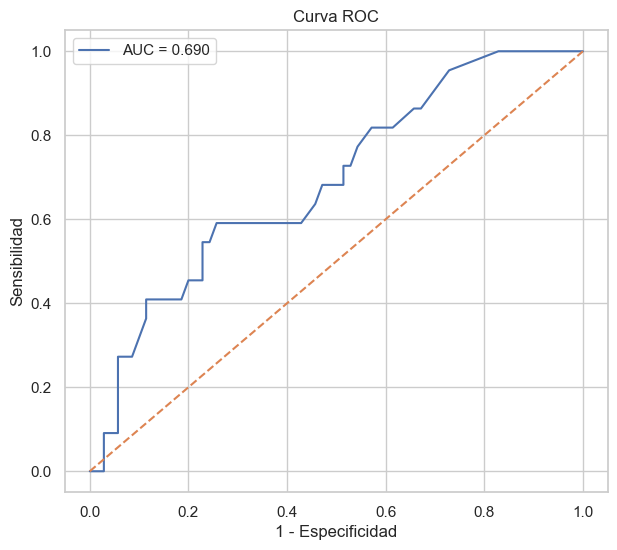

AUC = 0.6896103896103896


In [41]:
# ==========================================
# 22. CURVA ROC
# ==========================================

y_real = datos["pulso_alta"]
y_prob = datos["prob_alta"]

fpr, tpr, thresholds = roc_curve(
    y_real,
    y_prob
)

auc = roc_auc_score(
    y_real,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")
plt.legend()

plt.show()

print("AUC =", auc)

Obtenemos:

$$ \boxed{AUC\approx0.690} $$
Interpretación

Un AUC de aproximadamente 0.69 indica una capacidad discriminativa moderada.

No estamos ante un modelo excelente, pero sí existe capacidad para distinguir entre individuos con pulsación normal y alta mejor que una clasificación aleatoria.

23. Modelo final

Nuestro resultado principal es:

$$ \boxed{ \log \left( \frac{\hat\pi_i}{1-\hat\pi_i} \right) = 1.987 + 1.193\,\text{fumador}_i - 0.0505\,\text{peso}_i } $$

con

$$ \hat\pi_i=P(Y_i=1). $$

Los principales resultados son:

| Variable | Coeficiente |    OR | p-valor |
| -------- | ----------: | ----: | ------: |
| Fumador  |       1.193 | 3.297 |   0.031 |
| Peso     |     -0.0505 | 0.951 |   0.041 |


# 24. Conclusión estadística

Una conclusión apropiada para el informe sería:

El análisis mediante regresión logística indica que la condición de fumador y el peso están asociados con la probabilidad de presentar pulsación alta en reposo. Manteniendo constante el peso, los fumadores presentan aproximadamente 3.30 veces las odds de presentar pulsación alta respecto a los no fumadores (OR = 3.30; IC95%: 1.12–9.75; p = 0.031). Por otra parte, manteniendo constante la condición de fumador, cada kilogramo adicional de peso se asocia con una reducción aproximada del 4.9 % en las odds de presentar pulsación alta (OR = 0.951; IC95%: 0.906–0.998; p = 0.041). La comparación con el modelo nulo muestra evidencia de que las variables incluidas aportan información significativa (prueba de razón de verosimilitudes, p ≈ 0.023). El diagnóstico no evidencia problemas graves de multicolinealidad y la prueba de Hosmer-Lemeshow no detecta falta de ajuste significativa (p ≈ 0.690). Sin embargo, se identifican algunas observaciones con residuos relativamente grandes, leverage elevado o influencia potencial, por lo que deben ser revisadas. La capacidad discriminativa del modelo es moderada, con AUC ≈ 0.690.